In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

nlp = spacy.load("en_core_web_sm")

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
import numpy as np
import time

size = 10_000_000
data = np.random.rand(size)

# NumPy vectorized sum
start_np = time.time()
np_sum = np.sum(data)
end_np = time.time()

# Manual Python loop
start_py = time.time()
manual_sum = 0

for val in data:
    manual_sum += val

end_py = time.time()

print(f"NumPy Sum : {np_sum:.2f} | Time: {end_np - start_np:.5f} sec")
print(f"Manual Sum: {manual_sum:.2f} | Time: {end_py - start_py:.5f} sec")
print()
print(f"NumPy is {(end_py - start_py) / (end_np - start_np):.0f}x faster on this machine.")

NumPy Sum : 4999507.35 | Time: 0.01300 sec
Manual Sum: 4999507.35 | Time: 2.75970 sec

NumPy is 212x faster on this machine.


In [5]:
%pip install selenium

Note: you may need to restart the kernel to use updated packages.


In [9]:
import selenium
print("Selenium installed successfully!")
print(selenium.__version__)

Selenium installed successfully!
4.49.0


In [6]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from bs4 import BeautifulSoup
import pandas as pd
import time

urls = [
    "https://techncruncher.blogspot.com/2025/01/top-10-ai-tools-that-will-transform.html",
    "https://techncruncher.blogspot.com/2023/12/limewire-ai-studio-review-2023-details.html",
    "https://techncruncher.blogspot.com/2023/01/top-10-ai-tools-in-2023-that-will-make.html",
    "https://techncruncher.blogspot.com/2022/11/top-10-ai-content-generator-writer.html",
    "https://techncruncher.blogspot.com/2022/03/prowritingaid-vs-grammarly-which.html"
]

options = Options()
options.add_argument("--headless")
options.add_argument("--disable-gpu")
options.add_argument("--window-size=1920,1080")

driver = webdriver.Chrome(options=options)

articles = []

for url in urls:
    try:
        driver.get(url)
        time.sleep(2)

        soup = BeautifulSoup(driver.page_source, "html.parser")
        article = soup.select_one("div.post-inner-area")

        if not article:
            print("[SKIP] Article container not found:", url)
            continue

        title = article.select_one("h1.entry-title")

        if not title:
            print("[SKIP] Title not found:", url)
            continue

        title_text = title.get_text(" ", strip=True)

        text = article.get_text(" ", strip=True)

        if len(text) < 500:
            print("[SKIP] Article too short:", url)
            continue

        articles.append({
            "url": url,
            "title": title_text,
            "text": text
        })

        print("[OK]", title_text)

    except Exception as e:
        print("[ERROR]", url, e)

driver.quit()

articles_raw = pd.DataFrame(articles)

print("\nScraped:", len(articles_raw), "articles")
articles_raw.head()

[OK] Top 10 AI Tools That Will Transform Your Content Creation in 2025
[OK] LimeWire AI Studio Review 2023: Details, Pricing & Features
[OK] Top 10 AI Tools in 2023 That Will Make Your Life Easier
[OK] Top 10 AI Content Generator & Writer Tools in 2022
[OK] ProWritingAid VS Grammarly: Which Grammar Checker is Better in (2022) ?

Scraped: 5 articles


,url,title,text
0,https://techncruncher.blogspot.com/2025/01/top...,Top 10 AI Tools That Will Transform Your Conte...,Home Top 10 AI Tools That Will Transform Your ...
1,https://techncruncher.blogspot.com/2023/12/lim...,"LimeWire AI Studio Review 2023: Details, Prici...",Home Ai LimeWire AI Studio Review 2023: Detail...
2,https://techncruncher.blogspot.com/2023/01/top...,Top 10 AI Tools in 2023 That Will Make Your Li...,Home Ai Top 10 AI Tools in 2023 That Will Make...
3,https://techncruncher.blogspot.com/2022/11/top...,Top 10 AI Content Generator & Writer Tools in ...,Home Content Writing Top 10 AI Content Generat...
4,https://techncruncher.blogspot.com/2022/03/pro...,ProWritingAid VS Grammarly: Which Grammar Chec...,Home Comparison ProWritingAid VS Grammarly: Wh...


In [7]:
# Save the raw scraped articles
articles_raw.to_csv("articles_raw.csv", index=False)

print("Saved articles_raw.csv")
print("Shape:", articles_raw.shape)
display(articles_raw[["title", "url"]])

Saved articles_raw.csv
Shape: (5, 3)


,title,url
0,Top 10 AI Tools That Will Transform Your Conte...,https://techncruncher.blogspot.com/2025/01/top...
1,"LimeWire AI Studio Review 2023: Details, Prici...",https://techncruncher.blogspot.com/2023/12/lim...
2,Top 10 AI Tools in 2023 That Will Make Your Li...,https://techncruncher.blogspot.com/2023/01/top...
3,Top 10 AI Content Generator & Writer Tools in ...,https://techncruncher.blogspot.com/2022/11/top...
4,ProWritingAid VS Grammarly: Which Grammar Chec...,https://techncruncher.blogspot.com/2022/03/pro...


In [8]:
# Task 2.3 — spaCy Feature Engineering

def extract_features(text):
    doc = nlp(text)

    num_tokens = len(doc)
    num_sentences = len(list(doc.sents))
    num_entities = len(doc.ents)
    num_nouns = sum(1 for token in doc if token.pos_ == "NOUN")

    return num_tokens, num_sentences, num_entities, num_nouns


features = articles_raw["text"].apply(extract_features)

articles_raw[
    ["num_tokens", "num_sentences", "num_entities", "num_nouns"]
] = pd.DataFrame(
    features.tolist(),
    index=articles_raw.index
)

print("Feature engineering completed!")

display(
    articles_raw[
        ["title", "num_tokens", "num_sentences", "num_entities", "num_nouns"]
    ]
)

Feature engineering completed!


,title,num_tokens,num_sentences,num_entities,num_nouns
0,Top 10 AI Tools That Will Transform Your Conte...,1719,66,89,488
1,"LimeWire AI Studio Review 2023: Details, Prici...",1891,72,120,448
2,Top 10 AI Tools in 2023 That Will Make Your Li...,2710,72,92,624
3,Top 10 AI Content Generator & Writer Tools in ...,3611,160,243,856
4,ProWritingAid VS Grammarly: Which Grammar Chec...,1690,90,71,381


In [9]:
# Additional features required before Task 2.4

from textblob import TextBlob

# Title length
articles_raw["title_length"] = articles_raw["title"].str.len()

# Sentiment features
articles_raw["sentiment_polarity"] = articles_raw["text"].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

articles_raw["sentiment_subjectivity"] = articles_raw["text"].apply(
    lambda x: TextBlob(x).sentiment.subjectivity
)

print("TextBlob + title features completed!")

display(
    articles_raw[
        [
            "title",
            "title_length",
            "sentiment_polarity",
            "sentiment_subjectivity"
        ]
    ]
)

TextBlob + title features completed!


,title,title_length,sentiment_polarity,sentiment_subjectivity
0,Top 10 AI Tools That Will Transform Your Conte...,65,0.242707,0.546375
1,"LimeWire AI Studio Review 2023: Details, Prici...",59,0.217283,0.564677
2,Top 10 AI Tools in 2023 That Will Make Your Li...,55,0.160072,0.437562
3,Top 10 AI Content Generator & Writer Tools in ...,50,0.294463,0.565638
4,ProWritingAid VS Grammarly: Which Grammar Chec...,71,0.174217,0.427130


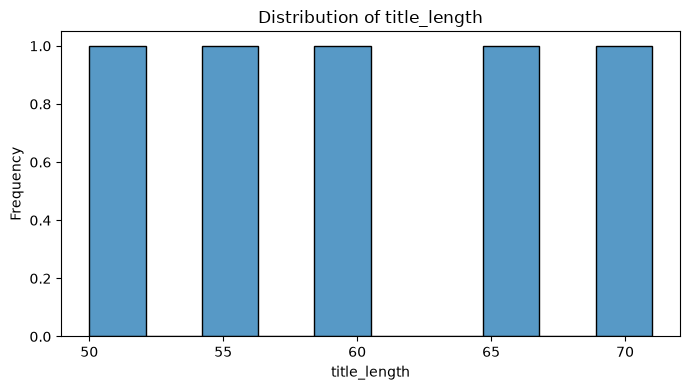

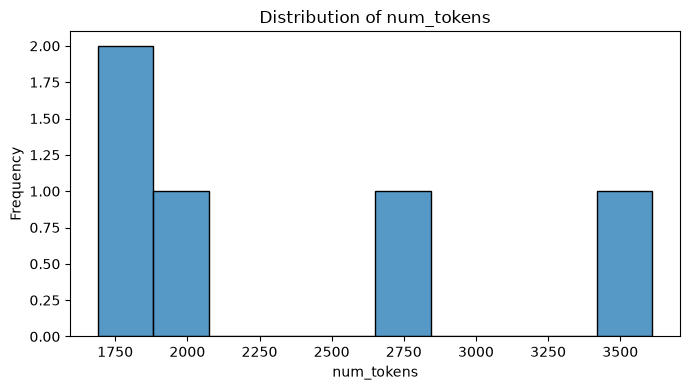

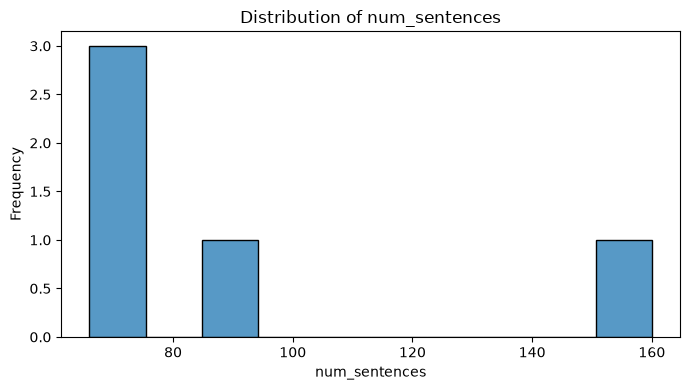

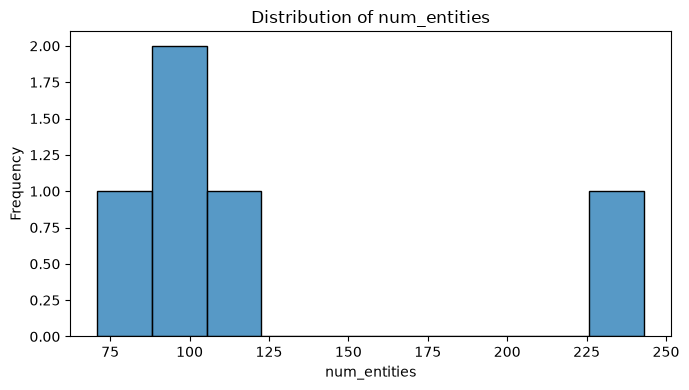

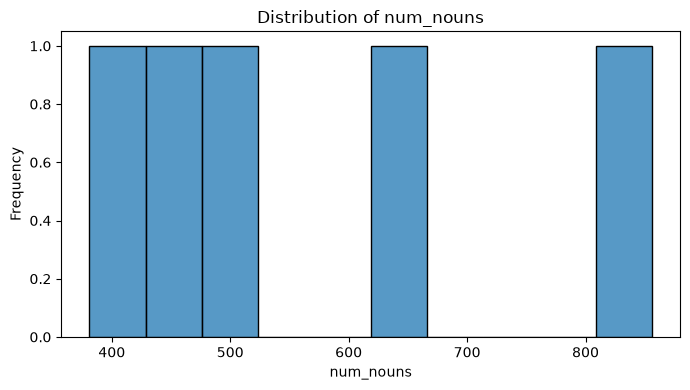

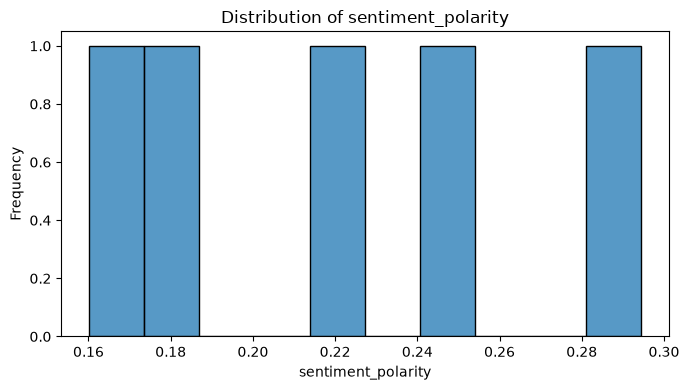

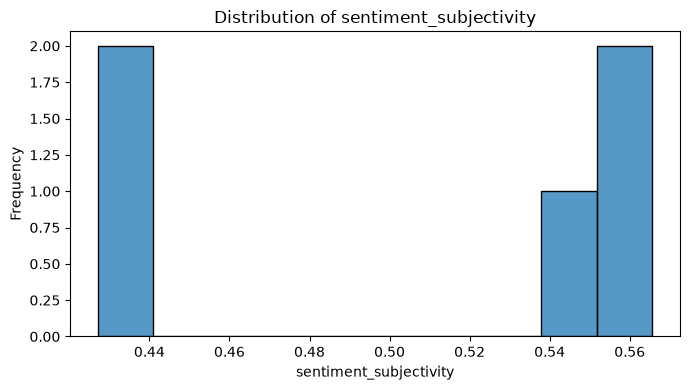

In [10]:
# Task 2.4-A — Individual Feature Distributions

feature_cols = [
    "title_length",
    "num_tokens",
    "num_sentences",
    "num_entities",
    "num_nouns",
    "sentiment_polarity",
    "sentiment_subjectivity"
]

for col in feature_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(articles_raw[col], bins=10, kde=False)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

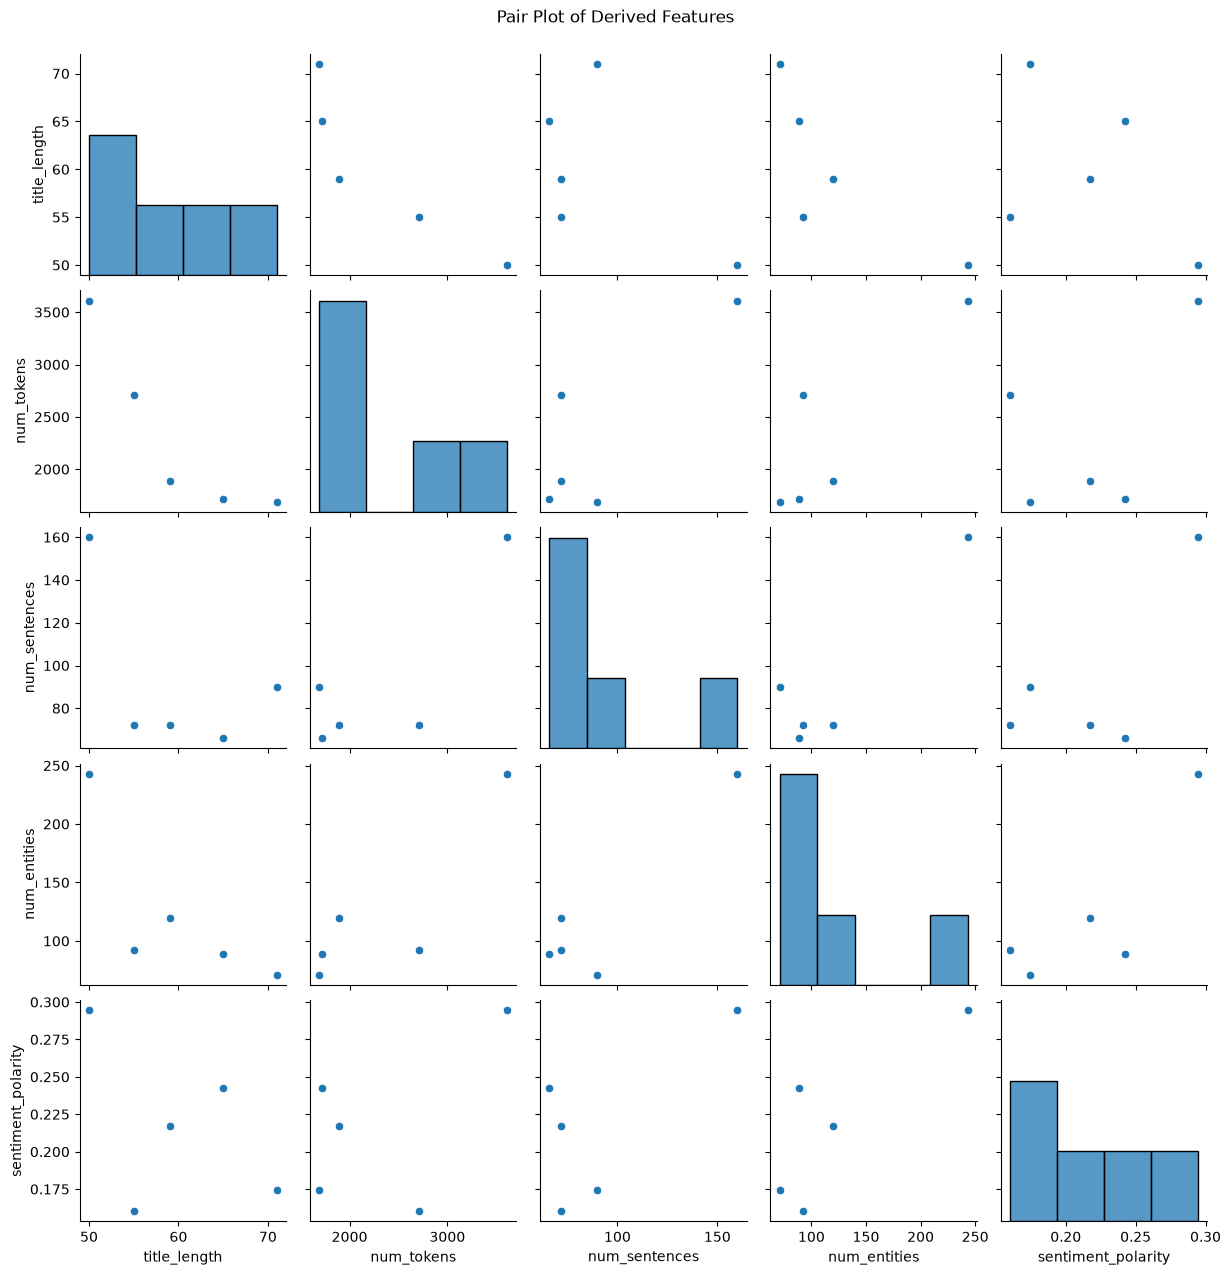

In [11]:
# Task 2.4-B — Pairwise Relationships

numeric_cols = [
    "title_length",
    "num_tokens",
    "num_sentences",
    "num_entities",
    "sentiment_polarity"
]

sns.pairplot(articles_raw[numeric_cols])
plt.suptitle("Pair Plot of Derived Features", y=1.02)
plt.show()

In [12]:
print("Correlation matrix:\n")

display(
    articles_raw[numeric_cols]
    .corr()
    .round(2)
)

Correlation matrix:



,title_length,num_tokens,num_sentences,num_entities,sentiment_polarity
title_length,1.00,-0.89,-0.55,-0.78,-0.47
num_tokens,-0.89,1.00,0.81,0.86,0.50
num_sentences,-0.55,0.81,1.00,0.91,0.69
num_entities,-0.78,0.86,0.91,1.00,0.83
sentiment_polarity,-0.47,0.50,0.69,0.83,1.00


In [13]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [14]:
# Task 2.4-C — TF-IDF Analysis

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=50
)

tfidf_matrix = vectorizer.fit_transform(articles_raw["text"])

feature_names = vectorizer.get_feature_names_out()
tfidf_scores = tfidf_matrix.mean(axis=0).A1

tfidf_df = pd.DataFrame({
    "term": feature_names,
    "tfidf": tfidf_scores
}).sort_values("tfidf", ascending=False)

print("Top 20 TF-IDF terms:")
display(tfidf_df.head(20))

Top 20 TF-IDF terms:


,term,tfidf
8,content,0.336560
2,ai,0.310098
28,month,0.160049
21,grammarly,0.140407
25,limewire,0.137791
15,features,0.125702
49,writing,0.123153
35,prowritingaid,0.121626
12,creation,0.106839
41,tool,0.105872


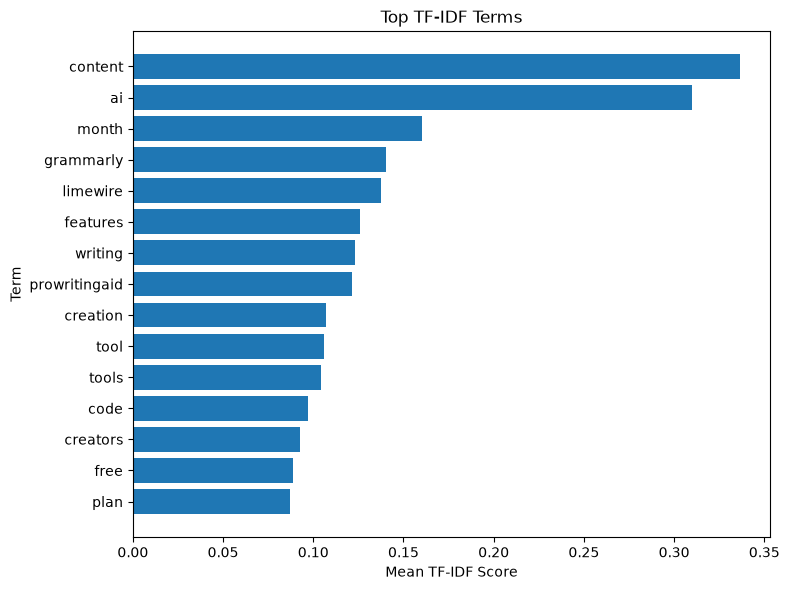

In [15]:
# Task 2.4-C — TF-IDF Visualization

top_n = 15
top_terms = tfidf_df.head(top_n).sort_values("tfidf")

plt.figure(figsize=(8, 6))
plt.barh(top_terms["term"], top_terms["tfidf"])

plt.title("Top TF-IDF Terms")
plt.xlabel("Mean TF-IDF Score")
plt.ylabel("Term")
plt.tight_layout()
plt.show()

In [16]:
extra_urls = [
    "https://techncruncher.blogspot.com/2022/07/top-10-ai-marketing-tools-you-should-use.html",
    "https://techncruncher.blogspot.com/2022/04/what-is-blockchain-everything-you-need.html"
]

In [17]:
# Exercise 1 — Add two URLs of our own choice

exercise_urls = urls + extra_urls

print("Total URLs:", len(exercise_urls))

for i, url in enumerate(exercise_urls, 1):
    print(f"{i}. {url}")

Total URLs: 7
1. https://techncruncher.blogspot.com/2025/01/top-10-ai-tools-that-will-transform.html
2. https://techncruncher.blogspot.com/2023/12/limewire-ai-studio-review-2023-details.html
3. https://techncruncher.blogspot.com/2023/01/top-10-ai-tools-in-2023-that-will-make.html
4. https://techncruncher.blogspot.com/2022/11/top-10-ai-content-generator-writer.html
5. https://techncruncher.blogspot.com/2022/03/prowritingaid-vs-grammarly-which.html
6. https://techncruncher.blogspot.com/2022/07/top-10-ai-marketing-tools-you-should-use.html
7. https://techncruncher.blogspot.com/2022/04/what-is-blockchain-everything-you-need.html


In [18]:
# Exercise 1 — Test all 7 pages

results = []

driver = webdriver.Chrome(options=options)

for url in exercise_urls:
    try:
        driver.get(url)
        time.sleep(3)

        soup = BeautifulSoup(driver.page_source, "html.parser")

        article = soup.select_one("div.post-inner-area")
        title = soup.select_one("h1.entry-title")

        if article and title:
            text = article.get_text(" ", strip=True)

            results.append({
                "url": url,
                "status": "SUCCESS",
                "title": title.get_text(" ", strip=True),
                "text_length": len(text)
            })

            print("[SUCCESS]", title.get_text(" ", strip=True))

        else:
            results.append({
                "url": url,
                "status": "FAILED",
                "title": "",
                "text_length": 0
            })

            print("[FAILED]", url)

    except Exception as e:
        results.append({
            "url": url,
            "status": "ERROR",
            "title": "",
            "text_length": 0
        })

        print("[ERROR]", url, "->", e)

driver.quit()

exercise_results = pd.DataFrame(results)

print("\nExercise 1 Results:")
display(exercise_results)

[SUCCESS] Top 10 AI Tools That Will Transform Your Content Creation in 2025
[SUCCESS] LimeWire AI Studio Review 2023: Details, Pricing & Features
[SUCCESS] Top 10 AI Tools in 2023 That Will Make Your Life Easier
[SUCCESS] Top 10 AI Content Generator & Writer Tools in 2022
[SUCCESS] ProWritingAid VS Grammarly: Which Grammar Checker is Better in (2022) ?
[SUCCESS] TOP 11 AI MARKETING TOOLS YOU SHOULD USE (Updated 2022)
[SUCCESS] What is Blockchain: Everything You Need to Know (2022)

Exercise 1 Results:


,url,status,title,text_length
0,https://techncruncher.blogspot.com/2025/01/top...,SUCCESS,Top 10 AI Tools That Will Transform Your Conte...,10001
1,https://techncruncher.blogspot.com/2023/12/lim...,SUCCESS,"LimeWire AI Studio Review 2023: Details, Prici...",10563
2,https://techncruncher.blogspot.com/2023/01/top...,SUCCESS,Top 10 AI Tools in 2023 That Will Make Your Li...,14199
3,https://techncruncher.blogspot.com/2022/11/top...,SUCCESS,Top 10 AI Content Generator & Writer Tools in ...,18719
4,https://techncruncher.blogspot.com/2022/03/pro...,SUCCESS,ProWritingAid VS Grammarly: Which Grammar Chec...,9505
5,https://techncruncher.blogspot.com/2022/07/top...,SUCCESS,TOP 11 AI MARKETING TOOLS YOU SHOULD USE (Upda...,11054
6,https://techncruncher.blogspot.com/2022/04/wha...,SUCCESS,What is Blockchain: Everything You Need to Kno...,9332


In [19]:
# Exercise 1 — Summary

print("Total pages tested:", len(exercise_results))
print("Successful pages:", (exercise_results["status"] == "SUCCESS").sum())
print("Failed pages:", (exercise_results["status"] == "FAILED").sum())
print("Errors:", (exercise_results["status"] == "ERROR").sum())

Total pages tested: 7
Successful pages: 7
Failed pages: 0
Errors: 0


In [20]:
# Exercise 2 — Extended Feature Extraction

def extract_features_extended(text):
    doc = nlp(text)
    sentences = list(doc.sents)

    return pd.Series({
        "num_tokens": len(doc),
        "num_sentences": len(sentences),
        "num_entities": len(doc.ents),
        "num_nouns": len([t for t in doc if t.pos_ == "NOUN"]),
        "num_verbs": len([t for t in doc if t.pos_ == "VERB"]),
        "avg_sentence_length": (len(doc) / len(sentences)) if sentences else 0.0
    })


extended = articles_raw["text"].apply(extract_features_extended)

df_ext = pd.concat(
    [articles_raw[["title"]], extended],
    axis=1
)

display(df_ext)

,title,num_tokens,num_sentences,num_entities,num_nouns,num_verbs,avg_sentence_length
0,Top 10 AI Tools That Will Transform Your Conte...,1719.0,66.0,89.0,488.0,170.0,26.045455
1,"LimeWire AI Studio Review 2023: Details, Prici...",1891.0,72.0,120.0,448.0,212.0,26.263889
2,Top 10 AI Tools in 2023 That Will Make Your Li...,2710.0,72.0,92.0,624.0,307.0,37.638889
3,Top 10 AI Content Generator & Writer Tools in ...,3611.0,160.0,243.0,856.0,384.0,22.568750
4,ProWritingAid VS Grammarly: Which Grammar Chec...,1690.0,90.0,71.0,381.0,187.0,18.777778


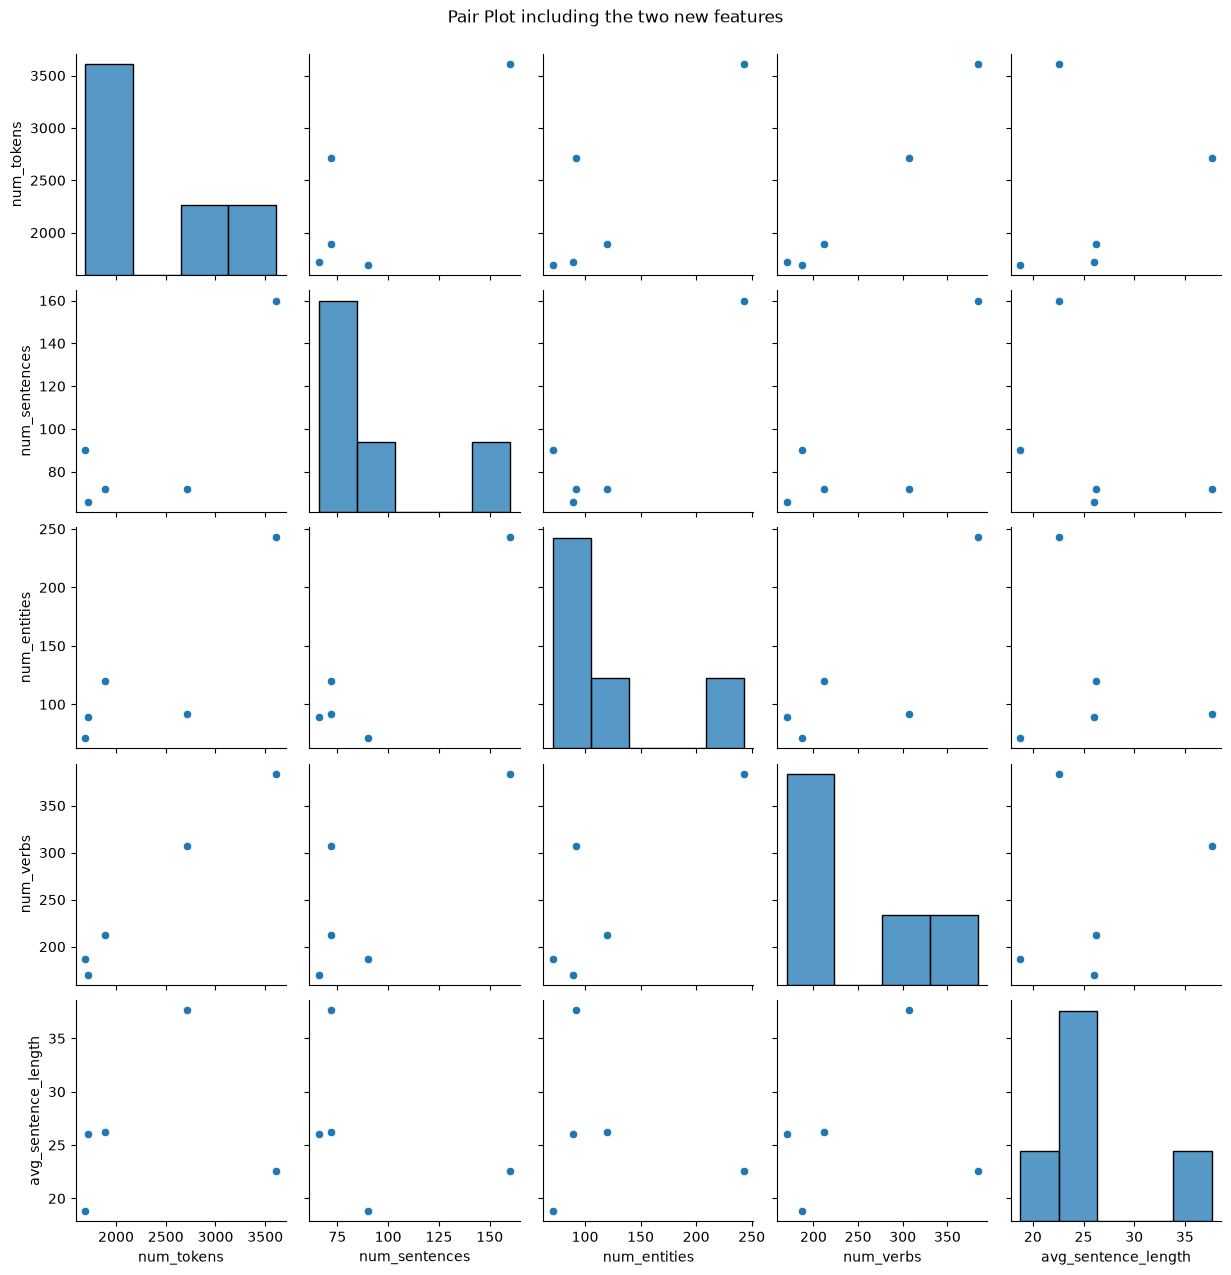

In [21]:
# Exercise 2 — Pair Plot with New Features

sns.pairplot(
    df_ext[
        [
            "num_tokens",
            "num_sentences",
            "num_entities",
            "num_verbs",
            "avg_sentence_length"
        ]
    ]
)

plt.suptitle(
    "Pair Plot including the two new features",
    y=1.02
)

plt.show()

### Exercise 3 — KDE with Five Articles

A kernel density estimate (KDE) computed from only five articles should not be
reported as the population distribution because five observations are too few
to reliably represent the underlying population. The KDE is only a smooth
description of these five observed values and can be strongly affected by each
individual observation and the chosen bandwidth.

Instead, with such a small sample, we should report the individual observed
values and use simple descriptive statistics such as the mean, median, minimum,
maximum, and range. If we want to make claims about a population distribution,
we should collect a substantially larger and more representative sample.
    

In [22]:
# Exercise 4 — TF-IDF with and without stop-word removal

vec_stop = TfidfVectorizer(
    stop_words="english",
    max_features=20
)

vec_none = TfidfVectorizer(
    stop_words=None,
    max_features=20
)

# With English stop-word removal
X_stop = vec_stop.fit_transform(articles_raw["text"])

tfidf_stop = pd.DataFrame(
    X_stop.toarray(),
    columns=vec_stop.get_feature_names_out()
)

top_stop = tfidf_stop.sum().sort_values(ascending=False)

# Without stop-word removal
X_none = vec_none.fit_transform(articles_raw["text"])

tfidf_none = pd.DataFrame(
    X_none.toarray(),
    columns=vec_none.get_feature_names_out()
)

top_none = tfidf_none.sum().sort_values(ascending=False)

print("TOP 20 — stop_words='english'")
display(top_stop.to_frame("tfidf_sum"))

print("\nTOP 20 — stop_words=None")
display(top_none.to_frame("tfidf_sum"))

TOP 20 — stop_words='english'


,tfidf_sum
content,1.979331
ai,1.834951
month,0.903243
grammarly,0.768696
features,0.749237
limewire,0.732122
writing,0.725537
tool,0.723801
prowritingaid,0.638087
tools,0.632642



TOP 20 — stop_words=None


,tfidf_sum
and,2.138996
the,1.868160
to,1.805636
content,1.229663
for,1.188961
ai,1.071840
of,0.934447
you,0.906642
it,0.829925
in,0.789393


In [23]:
# Compare the two results

print("Terms with stop-word removal:")
print(list(top_stop.index))

print("\nTerms without stop-word removal:")
print(list(top_none.index))

Terms with stop-word removal:
['content', 'ai', 'month', 'grammarly', 'features', 'limewire', 'writing', 'tool', 'prowritingaid', 'tools', 'creation', 'free', 'plan', 'help', 'generate', 'generation', 'use', 'pricing', 'create', 'offers']

Terms without stop-word removal:
['and', 'the', 'to', 'content', 'for', 'ai', 'of', 'you', 'it', 'in', 'is', 'your', 'month', 'can', 'with', 'that', 'features', 'as', 'on', 'be']


### Exercise 4 — TF-IDF Comparison

When `stop_words='english'` is used, common English stop words are removed
before calculating TF-IDF. Therefore, the top terms are more content-specific,
such as `content`, `ai`, `grammarly`, `features`, `writing`, and `prowritingaid`.

When `stop_words=None` is used, stop words are kept in the vocabulary. As a
result, common words such as `and`, `the`, `to`, `for`, `of`, `you`, and `it`
appear among the top twenty terms.

Therefore, removing stop words makes the TF-IDF results more focused on
terms that are characteristic of the articles, while keeping stop words causes
frequently occurring common English words to appear in the ranking.

In [24]:
# Home Assignment — Source 2
# Collect 10 article URLs from Top10AI

second_blog = "https://top10ai.com/blog/"

driver = webdriver.Chrome(options=options)

driver.get(second_blog)
time.sleep(4)

soup = BeautifulSoup(driver.page_source, "html.parser")

second_links = []

for a in soup.find_all("a", href=True):
    href = a["href"]
    text = a.get_text(" ", strip=True)

    if href.startswith("/"):
        href = "https://top10ai.com" + href

    if (
        href.startswith("https://top10ai.com/")
        and href != second_blog
        and text
        and href not in [x[1] for x in second_links]
    ):
        second_links.append((text, href))

driver.quit()

second_links = second_links[:10]

print("Second blog articles found:", len(second_links))

for i, (title, url) in enumerate(second_links, 1):
    print(f"{i}. {title[:80]}")
    print(f"   {url}")

Second blog articles found: 10
1. ★ Top 10 AI
   https://top10ai.com/
2. Video
   https://top10ai.com/index-ai-video-tools/
3. Image
   https://top10ai.com/index-ai-image-editor-tools/
4. Logo
   https://top10ai.com/index-ai-logo-generators/
5. Website
   https://top10ai.com/index-ai-website-builder/
6. Free Tools
   https://top10ai.com/free-ai-tools/
7. Compare
   https://top10ai.com/compare/
8. ES Español
   https://top10ai.com/es/blog/
9. DE Deutsch
   https://top10ai.com/de/blog/
10. FR Français
   https://top10ai.com/fr/blog/


In [26]:
# Find actual Top10AI article links

driver = webdriver.Chrome(options=options)
driver.get("https://top10ai.com/blog/")
time.sleep(4)

soup = BeautifulSoup(driver.page_source, "html.parser")

article_links = []

for a in soup.find_all("a", href=True):
    href = a["href"]
    text = a.get_text(" ", strip=True)

    # Convert relative URL to absolute
    if href.startswith("/"):
        href = "https://top10ai.com" + href

    # Keep likely article pages, exclude navigation/category pages
    excluded = [
        "/blog/",
        "/compare/",
        "/free-ai-tools/",
        "/index-",
        "/es/",
        "/de/",
        "/fr/",
        "/ar/",
        "/el/"
    ]

    if (
        href.startswith("https://top10ai.com/")
        and text
        and href != "https://top10ai.com/"
        and not any(x in href for x in excluded)
        and href not in [x[1] for x in article_links]
    ):
        article_links.append((text, href))

print("Possible article links:", len(article_links))

for i, (title, url) in enumerate(article_links[:15], 1):
    print(f"{i}. {title[:100]}")
    print(f"   {url}")

Possible article links: 284
1. Find my tool →
   https://top10ai.com/ai-tool-finder/
2. Sep 20, 2026 GPT-6 Astra Explained: Capabilities, API Pricing and What to Test A sourced guide to GP
   https://top10ai.com/gpt-6-astra-explained/
3. Sep 20, 2026 What Is Jev? TypeSafe’s AI for Decisions Inside Software What Jev does, where typed AI 
   https://top10ai.com/jev-system-one-explained/
4. Sep 20, 2026 AI For Schools: Complete Guide for 2026 The classroom of tomorrow isn’t some distant vi
   https://top10ai.com/ai-for-schools/
5. Sep 20, 2026 Best AI For Teachers in 2026: Top Picks Reviewed Best Best AI For Teachers in 2026: Top
   https://top10ai.com/best-ai-for-teachers/
6. Sep 19, 2026 What Is The Best AI Chatbot: Complete Guide for 2026 By 2026, AI chatbots aren’t just n
   https://top10ai.com/what-is-the-best-ai-chatbot/
7. Sep 18, 2026 Best AI Coding Assistant in 2026: Top Picks Reviewed In 2026, the question isn’t whethe
   https://top10ai.com/best-ai-coding-assistant/
8. Sep 17, 

In [27]:
second_article_urls = [
    "https://top10ai.com/gpt-6-astra-explained/",
    "https://top10ai.com/jev-system-one-explained/",
    "https://top10ai.com/ai-for-schools/",
    "https://top10ai.com/best-ai-for-teachers/",
    "https://top10ai.com/what-is-the-best-ai-chatbot/",
    "https://top10ai.com/best-ai-coding-assistant/",
    "https://top10ai.com/claude-ai-vs-chatgpt/",
    "https://top10ai.com/ai-detection-tool/",
    "https://top10ai.com/ai-software-for-small-business/",
    "https://top10ai.com/ai-cover-letter/"
]

print("Selected articles:", len(second_article_urls))

for i, url in enumerate(second_article_urls, 1):
    print(i, url)

Selected articles: 10
1 https://top10ai.com/gpt-6-astra-explained/
2 https://top10ai.com/jev-system-one-explained/
3 https://top10ai.com/ai-for-schools/
4 https://top10ai.com/best-ai-for-teachers/
5 https://top10ai.com/what-is-the-best-ai-chatbot/
6 https://top10ai.com/best-ai-coding-assistant/
7 https://top10ai.com/claude-ai-vs-chatgpt/
8 https://top10ai.com/ai-detection-tool/
9 https://top10ai.com/ai-software-for-small-business/
10 https://top10ai.com/ai-cover-letter/


In [28]:
# Home Assignment — Scrape 10 articles from Source 2

second_articles = []

driver = webdriver.Chrome(options=options)

for i, url in enumerate(second_article_urls, 1):
    try:
        driver.get(url)
        time.sleep(3)

        soup = BeautifulSoup(driver.page_source, "html.parser")

        # Top10AI article content
        title_tag = soup.find("h1")

        # Try common content containers
        content = (
            soup.select_one(".entry-content")
            or soup.select_one(".post-content")
            or soup.select_one("main")
        )

        title = title_tag.get_text(" ", strip=True) if title_tag else "Unknown Title"
        text = content.get_text(" ", strip=True) if content else ""

        if len(text) > 200:
            second_articles.append({
                "title": title,
                "text": text,
                "source": "Top10AI",
                "url": url
            })

            print(f"[{i}/10] SUCCESS: {title[:80]}")
            print("Text length:", len(text))
        else:
            print(f"[{i}/10] SKIP — article text too short: {url}")

    except Exception as e:
        print(f"[{i}/10] ERROR: {url}")
        print(e)

driver.quit()

print("\nTotal Source 2 articles scraped:", len(second_articles))

[1/10] SUCCESS: GPT-6 Astra Explained: Capabilities, API Pricing and What to Test
Text length: 3994
[2/10] SUCCESS: What Is Jev? TypeSafe’s AI for Decisions Inside Software
Text length: 4038
[3/10] SUCCESS: AI For Schools: Complete Guide for 2026
Text length: 14669
[4/10] SUCCESS: Best AI For Teachers in 2026: Top Picks Reviewed
Text length: 26936
[5/10] SUCCESS: What Is The Best AI Chatbot: Complete Guide for 2026
Text length: 14339
[6/10] SUCCESS: Best Best AI Coding Assistant in 2026: Top Picks Reviewed
Text length: 23385
[7/10] SUCCESS: Claude AI Vs Chatgpt: Complete Comparison for 2026
Text length: 17415
[8/10] SUCCESS: AI Detection Tool: Complete Guide for 2026
Text length: 16945
[9/10] SUCCESS: AI Software For Small Business: Complete Guide for 2026
Text length: 17524
[10/10] SUCCESS: AI Cover Letter: Complete Guide for 2026
Text length: 17449

Total Source 2 articles scraped: 10


In [29]:
# Home Assignment — Combine both sources

# Source 1: existing 10 TechnCruncher articles
source1 = articles_raw.copy()
source1["source"] = "TechnCruncher"

# Source 2: Top10AI articles
source2 = pd.DataFrame(second_articles)

# Keep the same columns
source1 = source1[["title", "text", "source", "url"]]
source2 = source2[["title", "text", "source", "url"]]

# Combine
articles = pd.concat(
    [source1, source2],
    ignore_index=True
)

print("Total articles:", len(articles))
print("\nArticles by source:")
print(articles["source"].value_counts())

display(articles[["title", "source", "url"]])

Total articles: 15

Articles by source:
source
Top10AI          10
TechnCruncher     5
Name: count, dtype: int64


,title,source,url
0,Top 10 AI Tools That Will Transform Your Conte...,TechnCruncher,https://techncruncher.blogspot.com/2025/01/top...
1,"LimeWire AI Studio Review 2023: Details, Prici...",TechnCruncher,https://techncruncher.blogspot.com/2023/12/lim...
2,Top 10 AI Tools in 2023 That Will Make Your Li...,TechnCruncher,https://techncruncher.blogspot.com/2023/01/top...
3,Top 10 AI Content Generator & Writer Tools in ...,TechnCruncher,https://techncruncher.blogspot.com/2022/11/top...
4,ProWritingAid VS Grammarly: Which Grammar Chec...,TechnCruncher,https://techncruncher.blogspot.com/2022/03/pro...
5,"GPT-6 Astra Explained: Capabilities, API Prici...",Top10AI,https://top10ai.com/gpt-6-astra-explained/
6,What Is Jev? TypeSafe’s AI for Decisions Insid...,Top10AI,https://top10ai.com/jev-system-one-explained/
7,AI For Schools: Complete Guide for 2026,Top10AI,https://top10ai.com/ai-for-schools/
8,Best AI For Teachers in 2026: Top Picks Reviewed,Top10AI,https://top10ai.com/best-ai-for-teachers/
9,What Is The Best AI Chatbot: Complete Guide fo...,Top10AI,https://top10ai.com/what-is-the-best-ai-chatbot/


In [30]:
# Recover the missing 5 TechnCruncher articles

techncruncher_urls = [
    "https://techncruncher.blogspot.com/2022/11/top-10-ai-content-generator-writer.html",
    "https://techncruncher.blogspot.com/2022/03/prowritingaid-vs-grammarly-which.html",
    "https://techncruncher.blogspot.com/2022/09/cj-affiliate-ultimate-guide-to.html",
    "https://techncruncher.blogspot.com/2022/07/top-10-ai-marketing-tools-you-should-use.html",
    "https://techncruncher.blogspot.com/2022/04/what-is-blockchain-everything-you-need.html"
]

missing_articles = []

driver = webdriver.Chrome(options=options)

for i, url in enumerate(techncruncher_urls, 1):
    try:
        driver.get(url)
        time.sleep(3)

        soup = BeautifulSoup(driver.page_source, "html.parser")

        container = soup.select_one("div.post-inner-area")
        title_tag = soup.select_one("h1.entry-title")

        title = title_tag.get_text(" ", strip=True) if title_tag else ""
        text = container.get_text(" ", strip=True) if container else ""

        if len(text) > 200:
            missing_articles.append({
                "title": title,
                "text": text,
                "source": "TechnCruncher",
                "url": url
            })
            print(f"[{i}/5] SUCCESS: {title}")
        else:
            print(f"[{i}/5] SKIP: {url}")

    except Exception as e:
        print(f"[{i}/5] ERROR: {url}")
        print(e)

driver.quit()

print("\nMissing articles scraped:", len(missing_articles))

[1/5] SUCCESS: Top 10 AI Content Generator & Writer Tools in 2022
[2/5] SUCCESS: ProWritingAid VS Grammarly: Which Grammar Checker is Better in (2022) ?
[3/5] SUCCESS: Beginner Guide to CJ Affiliate (Commission Junction) in 2022
[4/5] SUCCESS: TOP 11 AI MARKETING TOOLS YOU SHOULD USE (Updated 2022)
[5/5] SUCCESS: What is Blockchain: Everything You Need to Know (2022)

Missing articles scraped: 5


In [31]:
# Home Assignment — Build final 20-article dataset

# Existing 5 TechnCruncher
tc_existing = articles_raw.copy()
tc_existing["source"] = "TechnCruncher"

# Recovered 5 TechnCruncher
tc_missing = pd.DataFrame(missing_articles)

# 10 Top10AI
top10ai_df = pd.DataFrame(second_articles)

# Keep consistent columns
tc_existing = tc_existing[["title", "text", "source", "url"]]
tc_missing = tc_missing[["title", "text", "source", "url"]]
top10ai_df = top10ai_df[["title", "text", "source", "url"]]

# Combine all 20
articles = pd.concat(
    [tc_existing, tc_missing, top10ai_df],
    ignore_index=True
)

print("Total articles:", len(articles))
print("\nArticles by source:")
print(articles["source"].value_counts())

display(articles[["title", "source", "url"]])

Total articles: 20

Articles by source:
source
TechnCruncher    10
Top10AI          10
Name: count, dtype: int64


,title,source,url
0,Top 10 AI Tools That Will Transform Your Conte...,TechnCruncher,https://techncruncher.blogspot.com/2025/01/top...
1,"LimeWire AI Studio Review 2023: Details, Prici...",TechnCruncher,https://techncruncher.blogspot.com/2023/12/lim...
2,Top 10 AI Tools in 2023 That Will Make Your Li...,TechnCruncher,https://techncruncher.blogspot.com/2023/01/top...
3,Top 10 AI Content Generator & Writer Tools in ...,TechnCruncher,https://techncruncher.blogspot.com/2022/11/top...
4,ProWritingAid VS Grammarly: Which Grammar Chec...,TechnCruncher,https://techncruncher.blogspot.com/2022/03/pro...
5,Top 10 AI Content Generator & Writer Tools in ...,TechnCruncher,https://techncruncher.blogspot.com/2022/11/top...
6,ProWritingAid VS Grammarly: Which Grammar Chec...,TechnCruncher,https://techncruncher.blogspot.com/2022/03/pro...
7,Beginner Guide to CJ Affiliate (Commission Jun...,TechnCruncher,https://techncruncher.blogspot.com/2022/09/cj-...
8,TOP 11 AI MARKETING TOOLS YOU SHOULD USE (Upda...,TechnCruncher,https://techncruncher.blogspot.com/2022/07/top...
9,What is Blockchain: Everything You Need to Kno...,TechnCruncher,https://techncruncher.blogspot.com/2022/04/wha...


In [32]:
# Home Assignment — Sentiment Polarity + Noun Density

from textblob import TextBlob

def calculate_features(text):
    # Sentiment polarity: -1 to +1
    polarity = TextBlob(text).sentiment.polarity

    # spaCy analysis
    doc = nlp(text)

    # Noun density = nouns / total tokens
    valid_tokens = [
        token for token in doc
        if not token.is_space and not token.is_punct
    ]

    nouns = [
        token for token in valid_tokens
        if token.pos_ == "NOUN"
    ]

    noun_density = (
        len(nouns) / len(valid_tokens)
        if valid_tokens else 0
    )

    return pd.Series({
        "sentiment_polarity": polarity,
        "noun_density": noun_density
    })


features = articles["text"].apply(calculate_features)

articles_analysis = pd.concat(
    [articles, features],
    axis=1
)

print("Analysis completed!")

display(
    articles_analysis[
        [
            "title",
            "source",
            "sentiment_polarity",
            "noun_density"
        ]
    ]
)

Analysis completed!


,title,source,sentiment_polarity,noun_density
0,Top 10 AI Tools That Will Transform Your Conte...,TechnCruncher,0.242707,0.334705
1,"LimeWire AI Studio Review 2023: Details, Prici...",TechnCruncher,0.217283,0.262813
2,Top 10 AI Tools in 2023 That Will Make Your Li...,TechnCruncher,0.160072,0.273246
3,Top 10 AI Content Generator & Writer Tools in ...,TechnCruncher,0.294463,0.268770
4,ProWritingAid VS Grammarly: Which Grammar Chec...,TechnCruncher,0.174217,0.256566
5,Top 10 AI Content Generator & Writer Tools in ...,TechnCruncher,0.294463,0.268770
6,ProWritingAid VS Grammarly: Which Grammar Chec...,TechnCruncher,0.174217,0.256566
7,Beginner Guide to CJ Affiliate (Commission Jun...,TechnCruncher,0.254044,0.234844
8,TOP 11 AI MARKETING TOOLS YOU SHOULD USE (Upda...,TechnCruncher,0.165394,0.274455
9,What is Blockchain: Everything You Need to Kno...,TechnCruncher,0.149748,0.229013


In [33]:
# Compare both sources

source_summary = (
    articles_analysis
    .groupby("source")[["sentiment_polarity", "noun_density"]]
    .mean()
)

print("Mean values by source:")
display(source_summary)

Mean values by source:


,sentiment_polarity,noun_density
source,,
TechnCruncher,0.212661,0.265975
Top10AI,0.185539,0.253443


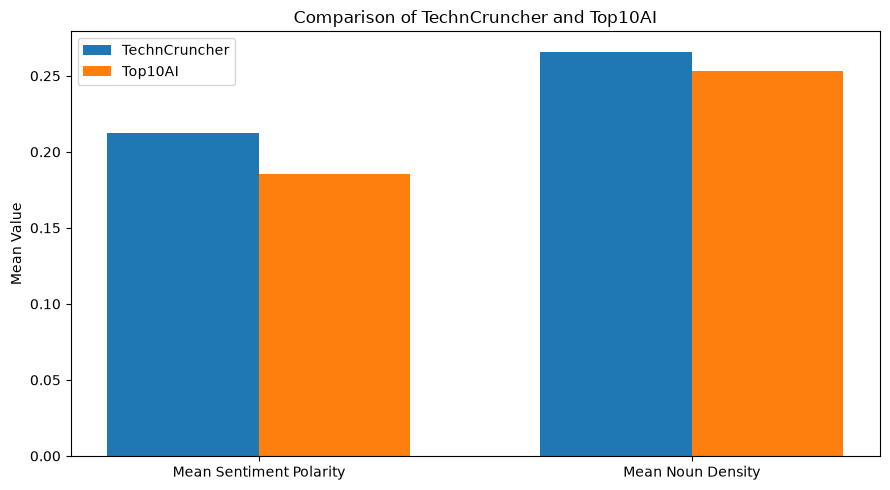

Sentiment polarity difference: 0.027122
Noun density difference: 0.012532


In [34]:
# Home Assignment — Grouped Bar Chart + Numerical Differences

import matplotlib.pyplot as plt
import numpy as np

metrics = ["sentiment_polarity", "noun_density"]

techncruncher_values = source_summary.loc[
    "TechnCruncher", metrics
].values

top10ai_values = source_summary.loc[
    "Top10AI", metrics
].values

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    techncruncher_values,
    width,
    label="TechnCruncher"
)

plt.bar(
    x + width/2,
    top10ai_values,
    width,
    label="Top10AI"
)

plt.xticks(
    x,
    ["Mean Sentiment Polarity", "Mean Noun Density"]
)

plt.ylabel("Mean Value")
plt.title("Comparison of TechnCruncher and Top10AI")
plt.legend()

plt.tight_layout()
plt.show()

# Numerical differences
sentiment_diff = (
    source_summary.loc["TechnCruncher", "sentiment_polarity"]
    - source_summary.loc["Top10AI", "sentiment_polarity"]
)

noun_density_diff = (
    source_summary.loc["TechnCruncher", "noun_density"]
    - source_summary.loc["Top10AI", "noun_density"]
)

print("Sentiment polarity difference:", round(sentiment_diff, 6))
print("Noun density difference:", round(noun_density_diff, 6))

## Home Assignment — Interpretation

The analysis compares 10 articles from TechnCruncher with 10 articles from
Top10AI.

TechnCruncher had a mean sentiment polarity of 0.212661, while Top10AI had a
mean sentiment polarity of 0.185539. The observed difference was 0.027122.
Both values are positive, indicating that the articles in both samples had
overall positive sentiment according to TextBlob.

For noun density, TechnCruncher had a mean value of 0.265975, compared with
0.253443 for Top10AI. The observed difference was 0.012532, meaning that the
TechnCruncher sample had a slightly higher proportion of nouns.

However, each source contains only 10 articles. Therefore, these results
describe the selected samples and should not be treated as representative of
the entire websites or all of their published articles. A larger and more
systematically selected sample would provide stronger evidence for making
broader comparisons.

In [35]:
# Save final dataset

articles_analysis.to_csv(
    "articles.csv",
    index=False
)

print("Saved articles.csv")
print("Rows:", len(articles_analysis))
print("Columns:", len(articles_analysis.columns))

Saved articles.csv
Rows: 20
Columns: 6


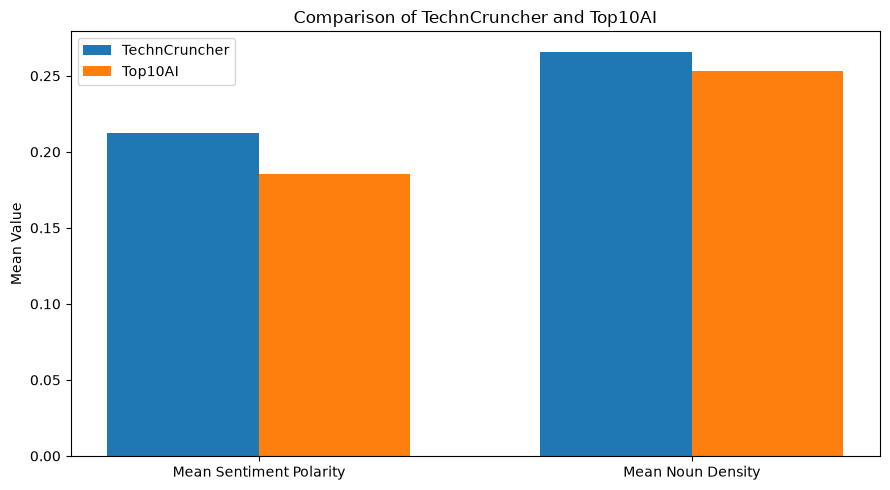

Saved: source_comparison.png


In [36]:
# Save the grouped bar chart

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    techncruncher_values,
    width,
    label="TechnCruncher"
)

plt.bar(
    x + width/2,
    top10ai_values,
    width,
    label="Top10AI"
)

plt.xticks(
    x,
    ["Mean Sentiment Polarity", "Mean Noun Density"]
)

plt.ylabel("Mean Value")
plt.title("Comparison of TechnCruncher and Top10AI")
plt.legend()

plt.tight_layout()

plt.savefig("source_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: source_comparison.png")

In [37]:
report = """# Lab 02 Report

## Objective

This analysis compares articles from two different AI-related blogs using sentiment polarity and noun density.

## Data Sources

The dataset contains 20 articles:

- 10 articles from TechnCruncher
- 10 articles from Top10AI

The `source` column identifies the blog for each article.

## Methodology

### Sentiment Polarity

TextBlob was used to calculate sentiment polarity for each article. Polarity values range from negative to positive, with values above zero indicating positive sentiment.

### Noun Density

spaCy was used to identify nouns. Noun density was calculated as:

Noun Density = Number of Nouns / Number of Valid Tokens

Punctuation, spaces, and other non-content tokens were excluded from the denominator.

## Results

| Source | Mean Sentiment Polarity | Mean Noun Density |
|---|---:|---:|
| TechnCruncher | 0.212661 | 0.265975 |
| Top10AI | 0.185539 | 0.253443 |

### Differences

- Sentiment polarity difference: **0.027122**
- Noun density difference: **0.012532**

TechnCruncher has a higher mean sentiment polarity and a higher mean noun density in this sample. Both sources have positive mean sentiment polarity values according to TextBlob.

## Visualization

The grouped bar chart compares the mean sentiment polarity and mean noun density of the two sources.

The figure is saved as `source_comparison.png`.

## Sample-Size Interpretation

The analysis uses 10 articles from each source. Therefore, the results describe the selected samples rather than the entire websites. The differences should not be treated as representative of all articles published by either source. A larger and more systematic sample would be needed to make stronger generalizations.

## Conclusion

The 20-article sample shows differences between TechnCruncher and Top10AI in both mean sentiment polarity and mean noun density. TechnCruncher has a mean sentiment polarity of 0.212661 compared with 0.185539 for Top10AI, while mean noun density is 0.265975 compared with 0.253443. These results are limited by the small sample size.
"""

with open("report.md", "w", encoding="utf-8") as f:
    f.write(report)

print("Saved: report.md")

Saved: report.md


In [38]:
import os

print("Files in lab02:")
for f in sorted(os.listdir(".")):
    print(f)

Files in lab02:
.ipynb_checkpoints
articles.csv
articles_raw.csv
report.md
scraping_eda.ipynb
source_comparison.png
untitled.py
